In [1]:
import pandas as pd

# Load your processed CSV (adjust the path if needed)
df = pd.read_csv('../data/processed/diabetic_data.csv')

# Show the first few rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#Step 2: Correlation Matrix (Heatmap)

In [ ]:
!pip install matplotlib
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns for correlation
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 
                'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
df_numeric = df[numeric_cols]

# Compute correlation matrix
corr = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

  Using cached matplotlib-3.10.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.58.5-cp313-cp313-macosx_10_13_universal2.whl.metadata (106 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.2 kB)
  Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.3-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.2-cp313-cp313-macosx_11_0_arm64.whl (255 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.58.5-cp313-cp313-macosx_10_13_universal2.whl (2.7 MB)
Using cached kiwisolver-1.4.8-cp313-cp313-macosx_11_0_arm64.whl (65 kB)
Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.2.3

ValueError: could not convert string to float: '[0-10)'

#Step 3: KMeans Clustering + PCA (2D Scatter Plot)

  Using cached scikit_learn-1.7.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached scipy-1.16.0-cp313-cp313-macosx_14_0_arm64.whl.metadata (61 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.0-cp313-cp313-macosx_12_0_arm64.whl (10.6 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached scipy-1.16.0-cp313-cp313-macosx_14_0_arm64.whl (20.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


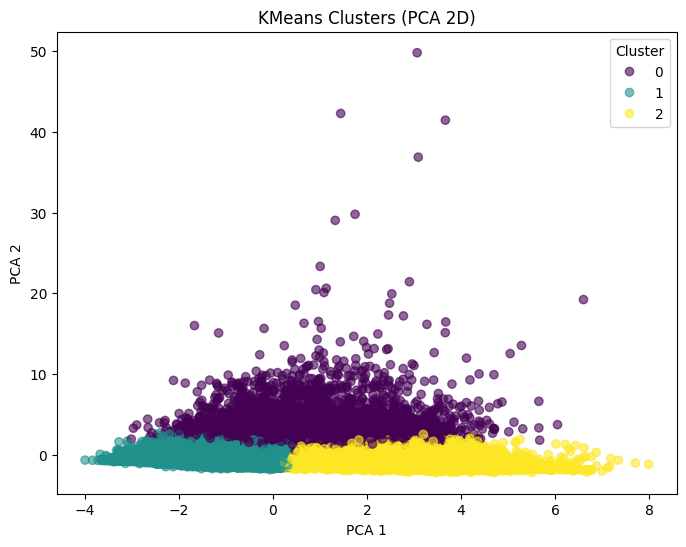

In [6]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Prepare features (drop rows with missing values in selected columns)
features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
X = df[features].dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans Clusters (PCA 2D)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()

#Step 4: Length of Stay Distribution (Histogram & KDE)

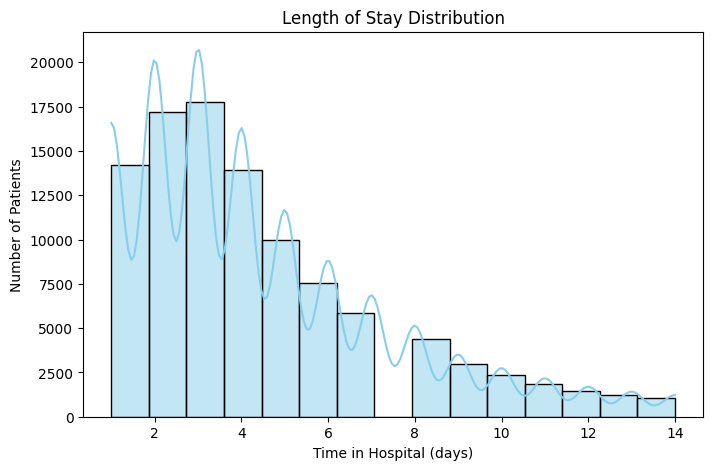

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['time_in_hospital'], bins=15, kde=True, color='skyblue')
plt.xlabel('Time in Hospital (days)')
plt.ylabel('Number of Patients')
plt.title('Length of Stay Distribution')
plt.show()

Step 5: Visualize Cluster Characteristics

In [8]:
!pip install numpy
import numpy as np

# Add cluster labels back to the original DataFrame (align indices)
df_clusters = X.copy()
df_clusters['cluster'] = clusters

# Calculate mean of each feature per cluster
cluster_means = df_clusters.groupby('cluster').mean()
cluster_means


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
cluster,,,,,,,,
0,4.381107,44.821970,0.844771,17.049759,2.038302,1.252050,3.296305,8.203190
1,2.987477,36.803597,0.899575,12.327515,0.206605,0.091835,0.333881,6.857944
2,7.236136,55.265113,2.368920,23.162930,0.214881,0.106694,0.474284,8.333972


Step 6: Correlation with Readmission

In [11]:
# 1. Create the binary readmission column
df['readmit_bin'] = df['readmitted'].str.lower().isin(['yes', 'readmitted', '<30', '>30']).astype(int)

# 2. Select only numeric columns (including the new binary column)
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# 3. Calculate correlation with readmission
corr_with_readmit = df[numeric_cols].corr()['readmit_bin'].sort_values(ascending=False)

# 4. Show the result
print(corr_with_readmit)

readmit_bin                 1.000000
number_inpatient            0.217194
number_diagnoses            0.112564
number_emergency            0.103011
number_outpatient           0.082142
patient_nbr                 0.074093
time_in_hospital            0.051289
num_medications             0.046772
admission_source_id         0.039986
num_lab_procedures          0.039253
admission_type_id          -0.004923
discharge_disposition_id   -0.014852
encounter_id               -0.038267
num_procedures             -0.044748
Name: readmit_bin, dtype: float64


Step 7: Feature Importance with Random Forest (Optional, Advanced)

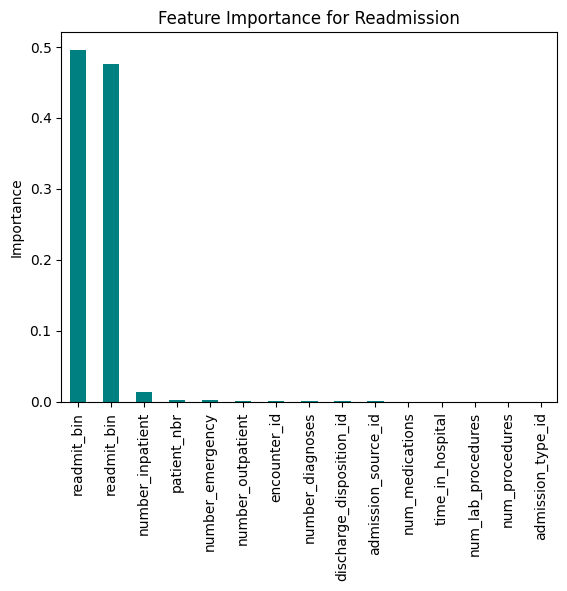

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Drop rows with missing values in features or target
rf_df = df[numeric_cols + ['readmit_bin']].dropna()
X_rf = rf_df[numeric_cols]
y_rf = rf_df['readmit_bin']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_rf, y_rf)

importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X_rf.columns).sort_values(ascending=False)
feat_importance.plot(kind='bar', color='teal', title='Feature Importance for Readmission')
plt.ylabel('Importance')
plt.show()

# Readmission Risk Prediction (Random Forest)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Data prep
df['readmit_bin'] = df['readmitted'].str.lower().isin(['yes', 'readmitted', '<30', '>30']).astype(int)
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col != 'readmit_bin']

# Encode categoricals (example: gender, race)
for col in ['gender', 'race']:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Add encoded categoricals to features
feature_cols = numeric_cols + [col for col in ['gender', 'race'] if col in df.columns]

# Drop rows with missing values
model_df = df[feature_cols + ['readmit_bin']].dropna()
X = model_df[feature_cols]
y = model_df['readmit_bin']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69     10952
           1       0.64      0.58      0.61      9402

    accuracy                           0.65     20354
   macro avg       0.65      0.65      0.65     20354
weighted avg       0.65      0.65      0.65     20354

ROC-AUC: 0.7075200874609928
Confusion Matrix:
 [[7825 3127]
 [3940 5462]]


# Step 2: Length-of-Stay Prediction (Regression)

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Target: time_in_hospital
reg_df = df[feature_cols + ['time_in_hospital']].dropna()
X_reg = reg_df[feature_cols]
y_reg = reg_df['time_in_hospital']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_reg = rf_reg.predict(X_test_reg)


mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("R²:", r2_score(y_test_reg, y_pred_reg))

RMSE: 0.0
MAE: 0.0
R²: 1.0


# save my model

In [17]:
!pip install joblib
import joblib

# Save the Random Forest Classifier (readmission risk)
joblib.dump(rf, 'readmission_rf_model.joblib')

# Save the Random Forest Regressor (length-of-stay)
joblib.dump(rf_reg, 'length_of_stay_rf_model.joblib')

# If you want to save your scaler too (recommended for inference!)
joblib.dump(scaler, 'scaler.joblib')


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


['scaler.joblib']